In [13]:
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../data/synthetic_dataset.csv', converters={'marker': eval})

In [14]:
df

,text,marker
0,Just reached the summit of Mt. Rainier!,"[[27, 38]]"
1,The Andes Mountains extend across South America.,"[[4, 19]]"
2,"When hiking through the Carpathian Mountains, ...","[[24, 44]]"
3,Mt Fuji was clearly visible from the train win...,"[[0, 7]]"
4,We camped near the foothills of the Himalayas ...,"[[32, 45]]"
...,...,...
1002,A view of Mount Kenya made the long drive wort...,"[[10, 21]]"
1003,"The Black Forest isn't a mountain range, but t...","[[56, 61]]"
1004,Yesterday we visited the Eiger and the Jungfra...,"[[25, 30], [39, 47]]"
1005,The Pennine Alps are part of the broader Alpin...,"[[4, 16]]"


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    1007 non-null   str   
 1   marker  1007 non-null   object
dtypes: object(1), str(1)
memory usage: 15.9+ KB


In [16]:
def split_markers(text, markers):
    splitted_markers = []
    
    for start, end in markers:
        
        # Extract the mountain name
        mountain_name = text[start:end]

        # Split the mountain name into individual words
        words = mountain_name.split(" ")

        # Generate separate marker for each word
        for word in words:
            word_start = text.find(word, start)
            word_end = word_start + len(word)
            splitted_markers.append((word_start, word_end))

    
    return splitted_markers


df['markers'] = df.apply(lambda row: split_markers(row['text'], row['marker']), axis=1)

In [17]:
df.head()

,text,marker,markers
0,Just reached the summit of Mt. Rainier!,"[[27, 38]]","[(27, 30), (31, 38)]"
1,The Andes Mountains extend across South America.,"[[4, 19]]","[(4, 9), (10, 19)]"
2,"When hiking through the Carpathian Mountains, ...","[[24, 44]]","[(24, 34), (35, 44)]"
3,Mt Fuji was clearly visible from the train win...,"[[0, 7]]","[(0, 2), (3, 7)]"
4,We camped near the foothills of the Himalayas ...,"[[32, 45]]","[(32, 35), (36, 45)]"


In [18]:
df['mountain_count'] = df['markers'].apply(len)
df['mountain_count'].value_counts(normalize=True)

mountain_count
2    0.711023
1    0.176763
3    0.058590
4    0.043694
5    0.007944
0    0.000993
8    0.000993
Name: proportion, dtype: float64

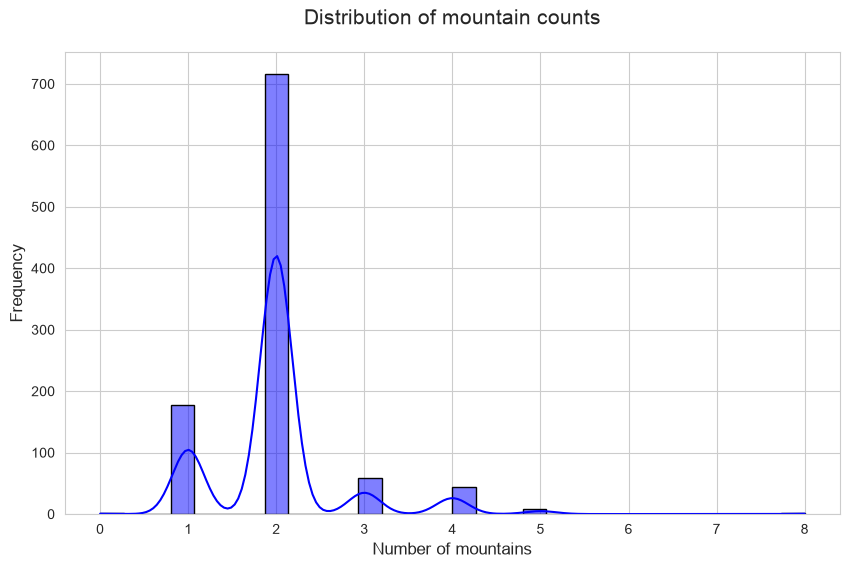

In [19]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

sns.histplot(df['mountain_count'], bins=30, kde=True, color='blue', edgecolor='black')

plt.title("Distribution of mountain counts", fontsize=15, pad=20)
plt.xlabel("Number of mountains", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.show()

In [20]:
def get_mountains(row):
    text, loc_markers = row['text'], row['markers']
    return [text[i:j] for i, j in loc_markers]

In [27]:
mountain_record = df[df['mountain_count'] >= 1].iloc[2]
print(mountain_record.text)

mountains = get_mountains(mountain_record)
print(f"Observed moutnains: {mountains}")

When hiking through the Carpathian Mountains, make sure to bring extra water.
Observed moutnains: ['Carpathian', 'Mountains']


In [22]:
mountains = df.apply(get_mountains, axis=1)

mountain_sub_titles = []

for mountain_title in mountains.to_list():
    for sub_title in mountain_title:
        mountain_sub_titles.append(sub_title)

pd.Series(mountain_sub_titles).value_counts()

Mount        276
Mountains    238
Range         55
Alps          45
Ben           35
            ... 
Valley         1
Vesuvius       1
Cader          1
Idris          1
Chiltern       1
Name: count, Length: 257, dtype: int64